# Ejercicio 6 - Parquet versus tablas DuckDB

Este cuaderno presenta el benchmark reproducible entre consultas directas a Parquet y una tabla materializada en DuckDB. Los datos incluyen Yellow y Green Taxi de 2024 y los meses disponibles de 2026.

## Metodologia

1. `sql/ejercicio_6_1.sql` materializa una tabla `trips` con columnas comunes y años validos.
2. `sql/ejercicio_6_2.sql` calcula conteos, promedios y percentiles de distancia.
3. `sql/ejercicio_6_3.sql` calcula volumen e ingresos mensuales.
4. `sql/ejercicio_6_4.sql` calcula distribucion de pagos y propinas.
5. `scripts/benchmark_ejercicio_6.py` sustituye solamente la fuente de cada consulta: union directa de Parquet o tabla `trips`.
6. Antes de medir se comprueba la igualdad de los DataFrames producidos por ambas estrategias.
7. Se realizan tres repeticiones y se alterna el orden de las estrategias. Se reporta la mediana.
8. Las mediciones representan ejecuciones calientes dentro de una misma conexion; no pretenden simular una primera lectura con cache de sistema operativo vacia.

Volumenes evaluados: 2026 parcial, 2024 completo y ambos años.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
cwd = Path.cwd().resolve()
ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
RESULTS = ROOT / 'docs' / 'benchmark_ejercicio_6.csv'
DATABASE = ROOT / 'data' / 'processed' / 'ejercicio_6.duckdb'

if not RESULTS.exists() or not DATABASE.exists():
    raise FileNotFoundError(
        'Ejecute primero: python scripts/benchmark_ejercicio_6.py --repetitions 3'
    )

results = pd.read_csv(RESULTS)
with duckdb.connect(str(DATABASE), read_only=True) as con:
    materialized_rows = con.execute('SELECT COUNT(*) FROM trips').fetchone()[0]

print(f'Resultados cargados: {len(results)} mediciones')
print(f'Filas en la tabla materializada: {materialized_rows:,}')
print(f'DuckDB usado en el benchmark: {results.duckdb_version.iloc[0]}')
print(f'CPU logicos registrados: {results.logical_cpus.iloc[0]}')

Resultados cargados: 54 mediciones
Filas en la tabla materializada: 71,094,351
DuckDB usado en el benchmark: 1.5.0
CPU logicos registrados: 8


## 6.5 Tiempos de ejecucion

La tabla siguiente organiza la mediana, minimo, maximo y desviacion estandar de cada consulta. `speedup_vs_parquet` indica cuantas veces tarda Parquet respecto de la tabla; valores mayores que 1 favorecen la tabla.

In [2]:
summary = (
    results.groupby(['scenario', 'years', 'row_count', 'query', 'strategy'], as_index=False)
    .agg(
        median_seconds=('seconds', 'median'),
        min_seconds=('seconds', 'min'),
        max_seconds=('seconds', 'max'),
        std_seconds=('seconds', 'std'),
    )
)

medians = summary.pivot(
    index=['scenario', 'years', 'row_count', 'query'],
    columns='strategy',
    values='median_seconds',
).reset_index()
medians['speedup_vs_parquet'] = medians['parquet'] / medians['duckdb_table']
display(medians.round(4))

strategy,scenario,years,row_count,query,duckdb_table,parquet,speedup_vs_parquet
0,2024_and_2026,2024+2026,71094351,q1_trip_characteristics,6.2060,6.2094,1.0005
1,2024_and_2026,2024+2026,71094351,q2_monthly_behavior,0.9041,1.2600,1.3937
2,2024_and_2026,2024+2026,71094351,q3_payment_distribution,0.6321,1.1051,1.7484
3,2024_full,2024,41216783,q1_trip_characteristics,3.5139,3.5002,0.9961
4,2024_full,2024,41216783,q2_monthly_behavior,0.4152,0.7494,1.8049
5,2024_full,2024,41216783,q3_payment_distribution,0.2772,0.6304,2.2744
6,2026_partial,2026,29877568,q1_trip_characteristics,2.6627,2.6059,0.9787
7,2026_partial,2026,29877568,q2_monthly_behavior,0.3043,0.5344,1.7559
8,2026_partial,2026,29877568,q3_payment_distribution,0.2093,0.4839,2.3117


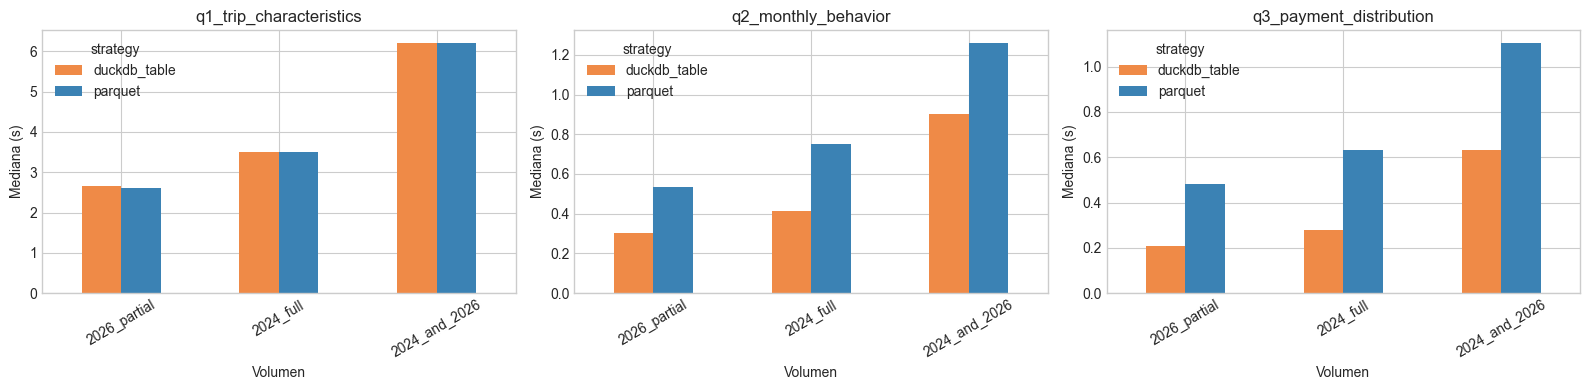

In [3]:
scenario_order = ['2026_partial', '2024_full', '2024_and_2026']
query_order = [
    'q1_trip_characteristics',
    'q2_monthly_behavior',
    'q3_payment_distribution',
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, query in zip(axes, query_order):
    subset = summary.query('query == @query').copy()
    chart = subset.pivot(index='scenario', columns='strategy', values='median_seconds').reindex(scenario_order)
    chart.plot(kind='bar', ax=ax, color={'parquet': '#3b82b4', 'duckdb_table': '#ef8a47'})
    ax.set(title=query, xlabel='Volumen', ylabel='Mediana (s)')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 6.6 Comportamiento al aumentar los datos

Se compara el cambio desde 2026 parcial hasta el conjunto combinado. El crecimiento no tiene que ser perfectamente lineal porque intervienen compresion, lectura selectiva de columnas, paralelismo y cache.

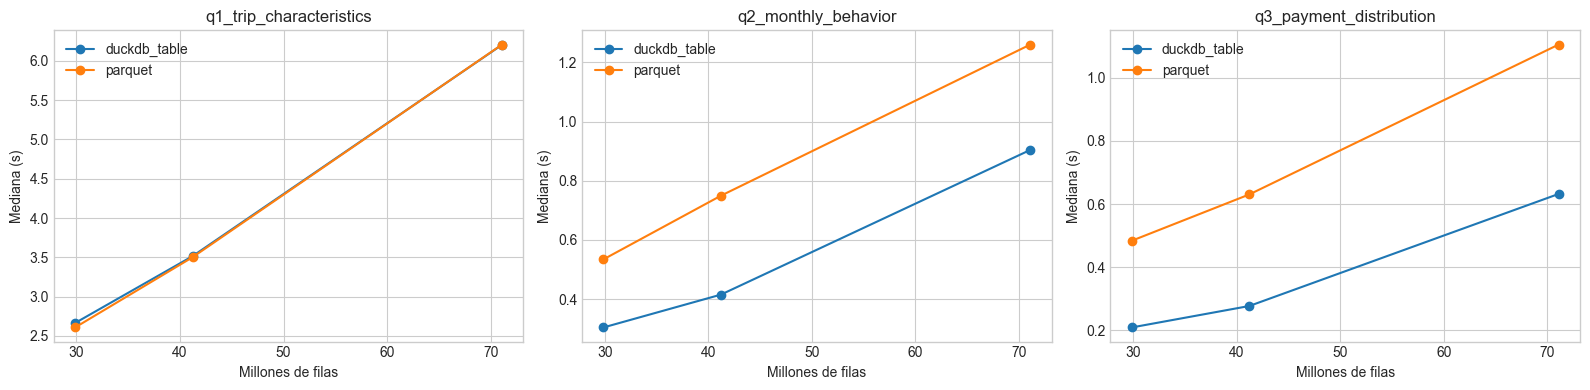

,query,parquet_growth,duckdb_table_growth
0,q1_trip_characteristics,2.38,2.33
1,q2_monthly_behavior,2.36,2.97
2,q3_payment_distribution,2.28,3.02


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, query in zip(axes, query_order):
    subset = summary.query('query == @query').sort_values('row_count')
    for strategy, group in subset.groupby('strategy'):
        ax.plot(group['row_count'] / 1_000_000, group['median_seconds'], marker='o', label=strategy)
    ax.set(title=query, xlabel='Millones de filas', ylabel='Mediana (s)')
    ax.legend()
plt.tight_layout()
plt.show()

small = medians.query("scenario == '2026_partial'").set_index('query')
large = medians.query("scenario == '2024_and_2026'").set_index('query')
growth = pd.DataFrame({
    'parquet_growth': large['parquet'] / small['parquet'],
    'duckdb_table_growth': large['duckdb_table'] / small['duckdb_table'],
}).reset_index()
display(growth.round(2))

## 6.9 Analisis de resultados

La consulta de percentiles domina su tiempo en el calculo de cuantiles sobre millones de valores. Como ambas fuentes utilizan el mismo motor columnar, la materializacion aporta poco y puede quedar ligeramente arriba o abajo por variacion normal. En cambio, las agregaciones mensuales y por pago evitan parte del costo de abrir y combinar varios Parquet cuando leen la tabla interna, por lo que muestran una mejora mas consistente.

In [5]:
materialization_seconds = results['materialization_seconds'].dropna().iloc[0]
combined = medians.query("scenario == '2024_and_2026'").copy()
combined['saved_seconds'] = combined['parquet'] - combined['duckdb_table']
suite_savings = combined['saved_seconds'].sum()
break_even = materialization_seconds / suite_savings if suite_savings > 0 else float('inf')

print(f'La materializacion inicial tomo {materialization_seconds:.3f} segundos.')
for row in combined.itertuples():
    print(
        f'{row.query}: Parquet {row.parquet:.4f} s, tabla {row.duckdb_table:.4f} s, '
        f'speedup {row.speedup_vs_parquet:.2f}x.'
    )
print(
    f'Con esta mezcla de tres consultas, el costo inicial se amortiza despues de '
    f'aproximadamente {break_even:.1f} ejecuciones completas del conjunto.'
)

La materializacion inicial tomo 12.804 segundos.
q1_trip_characteristics: Parquet 6.2094 s, tabla 6.2060 s, speedup 1.00x.
q2_monthly_behavior: Parquet 1.2600 s, tabla 0.9041 s, speedup 1.39x.
q3_payment_distribution: Parquet 1.1051 s, tabla 0.6321 s, speedup 1.75x.
Con esta mezcla de tres consultas, el costo inicial se amortiza despues de aproximadamente 15.4 ejecuciones completas del conjunto.


## 6.10 ¿Cuando usar cada estrategia?

### Consultar Parquet directamente

Es apropiado cuando los datos llegan como archivos nuevos, el analisis es exploratorio o poco frecuente, se desea evitar una copia adicional y las consultas leen pocas columnas gracias al formato columnar. Tambien simplifica un flujo incremental: agregar un archivo puede ser suficiente para que un patron glob lo incluya.

### Materializar una tabla DuckDB

Es conveniente cuando las mismas consultas se repiten, se necesita un esquema comun ya normalizado, se realizan uniones o transformaciones costosas, o una herramienta como Metabase requiere una fuente persistente. Debe considerarse el tiempo inicial, el espacio adicional y la necesidad de refrescar la tabla al llegar nuevos datos.

### Conclusion

La tabla no fue universalmente mas rapida: en percentiles ambas estrategias quedaron practicamente empatadas. Su ventaja aparecio en agregaciones repetitivas y simples. Por ello, la eleccion depende del tipo y frecuencia de las consultas, no solamente del numero de filas.